<a href="https://colab.research.google.com/github/TranNguyenMinhQuan/BaiTapDuLieuSau/blob/main/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   OrderID        Date CustomerID Product_Category            Product_Name  \
0  ORD0001  2025-11-24    CUST027         Clothing                   Jeans   
1  ORD0002  2025-02-27    CUST025      Electronics              Smartphone   
2  ORD0003  2025-01-13    CUST025            Books  Machine Learning Intro   
3  ORD0004  2025-05-21    CUST002   Home & Kitchen            Coffee Maker   
4  ORD0005  2025-05-06    CUST008      Electronics                  Laptop   
5  ORD0006  2025-04-25    CUST027      Electronics                  Laptop   
6  ORD0007  2025-03-13    CUST002            Books   Data Science Handbook   

   Quantity  UnitPrice  Discount   Region  
0         6      93.20      0.12  Central  
1        10     134.67       NaN    South  
2         9     178.20      0.04    North  
3         3     199.86      0.01    North  
4         7     144.85      0.17    North  
5         3     138.23       NaN  Central  
6         1      71.97      0.04    South  
    OrderID        Date

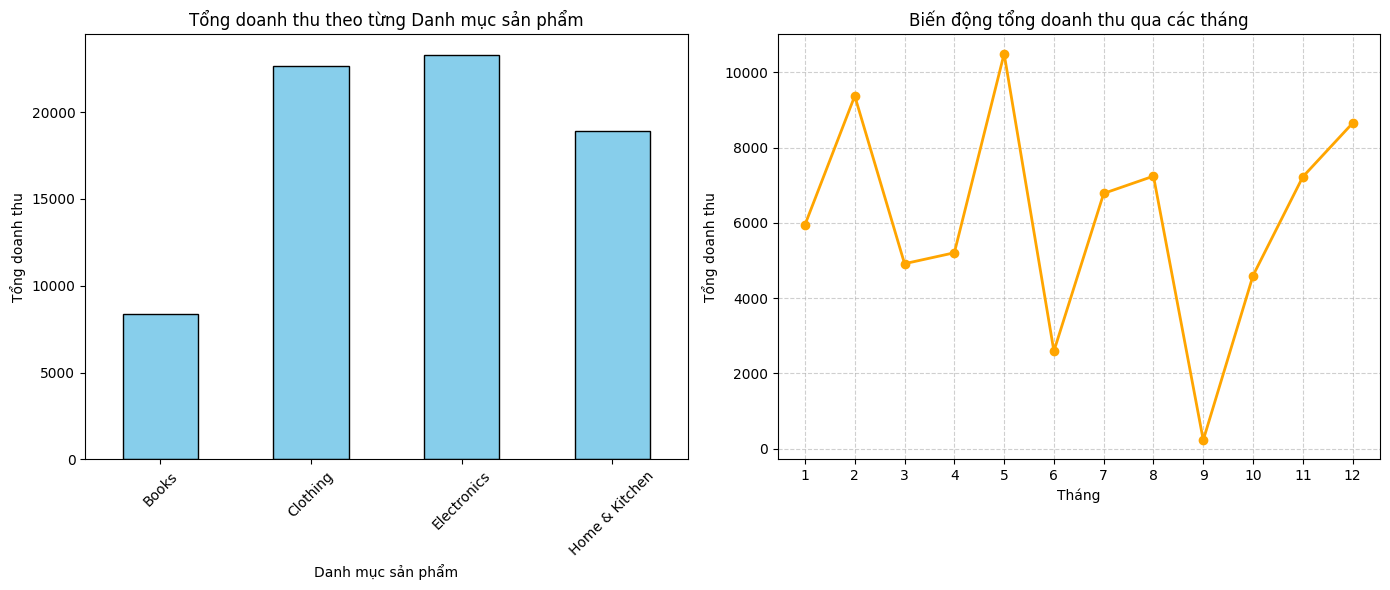

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Phần 1: Khởi tạo và Đọc dữ liệu

# 1. Import các thư viện cần thiết (pandas, matplotlib.pyplot) và đọc file dữ liệu ecommerce_sales_data.csv vào một DataFrame có tên là df.
df = pd.read_excel("ecommerce_sales_data.xlsx")

# 2. Hiển thị 7 dòng đầu tiên và 5 dòng cuối cùng của tập dữ liệu để có cái nhìn tổng quan.
print(df.head(7))
print(df.tail(5))

# 3. Sử dụng phương thức thích hợp để in ra thông tin tổng quan của cấu trúc dữ liệu (số lượng dòng, số lượng cột, kiểu dữ liệu của từng cột).
df.info()

# 4. Sử dụng hàm thống kê mô tả để hiển thị các chỉ số cơ bản (trung bình, độ lệch chuẩn, min, max...) của các cột dữ liệu dạng số.
print(df.describe())


# Phần 2: Khám phá và Làm sạch dữ liệu

# 1. Kiểm tra xem mỗi cột trong tập dữ liệu có bao nhiêu giá trị bị thiếu (NaN/Null).
print(df.isnull().sum())

# 2. Tiến hành xử lý giá trị thiếu ở cột Discount: Thay thế tất cả các giá trị bị thiếu bằng 0 (giả định đơn hàng không áp dụng giảm giá).
df["Discount"] = df["Discount"].fillna(0)

# 3. Tiến hành xử lý giá trị thiếu ở cột CustomerID: Thay thế tất cả các giá trị bị thiếu bằng chuỗi ký tự 'GUEST'
df["CustomerID"] = df["CustomerID"].fillna("GUEST")

# 4. Kiểm tra lại để đảm bảo tập dữ liệu không còn giá trị bị thiếu nào.
print(df.isnull().sum())

# 5. Chuyển đổi kiểu dữ liệu của cột Date từ chuỗi (object) sang kiểu dữ liệu thời gian (datetime).
df["Date"] = pd.to_datetime(df["Date"])

# 6. Kiểm tra xem có dữ liệu nào bị trùng lặp toàn bộ thông tin trên các cột không. Nếu có, hãy tiến hành loại bỏ các dòng trùng lặp đó.
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()


# Phần 3: Trích xuất và Biến đổi dữ liệu (Feature Engineering)

# 1. Tạo một cột mới tên là Revenue (Doanh thu). Biết công thức tính là: Revenue = Quantity * UnitPrice * (1 - Discount).
df["Revenue"] = df["Quantity"] * df["UnitPrice"] * (1 - df["Discount"])

# 2. Trích xuất Năm (Year) từ cột Date và lưu vào một cột mới tên là Year.
df["Year"] = df["Date"].dt.year

# 3. Trích xuất Tháng (Month) từ cột Date và lưu vào một cột mới tên là Month.
df["Month"] = df["Date"].dt.month

# 4. Trích xuất Ngày trong tuần (Day of Week) từ cột Date và lưu vào một cột mới tên là DayOfWeek (Hiển thị dưới dạng số hoặc tên ngày đều được).
df["DayOfWeek"] = df["Date"].dt.day_name()

# 5. Tạo một cột phân loại có tên là Price_Segment dựa trên đơn giá (UnitPrice) của sản phẩm: 'High' nếu UnitPrice >= 150, 'Medium' nếu 50 <= UnitPrice < 150, 'Low' nếu UnitPrice < 50.
def classify_price(price):
    if price >= 150:
        return "High"
    elif price >= 50:
        return "Medium"
    else:
        return "Low"


df["Price_Segment"] = df["UnitPrice"].apply(classify_price)


# Phần 4: Lọc và Truy vấn dữ liệu

# 1. Lọc và hiển thị danh sách các đơn hàng thuộc khu vực 'North' có doanh thu (Revenue) lớn hơn 300.
north_high_revenue = df[(df["Region"] == "North") & (df["Revenue"] > 300)]
print(north_high_revenue)

# 2. Có bao nhiêu đơn hàng mua sản phẩm thuộc danh mục 'Electronics' mà hoàn toàn không được giảm giá (Discount = 0)?
electronics_no_discount = df[
    (df["Product_Category"] == "Electronics") & (df["Discount"] == 0)
]
print(len(electronics_no_discount))

# 3. Lọc ra danh sách các đơn hàng mua trong khoảng thời gian từ tháng 3 đến tháng 6 của năm.
mar_to_jun_sales = df[(df["Month"] >= 3) & (df["Month"] <= 6)]
print(len(mar_to_jun_sales))

# 4. Chỉ hiển thị các cột OrderID, Product_Name, và Revenue cho 10 đơn hàng có doanh thu cao nhất.
top10_revenue = df.nlargest(10, "Revenue")[
    ["OrderID", "Product_Name", "Revenue"]
]
print(top10_revenue)

# 5. Tìm và hiển thị thông tin chi tiết của đơn hàng có số lượng (Quantity) mua nhiều nhất trong một lần giao dịch.
max_quantity_order = df[df["Quantity"] == df["Quantity"].max()]
print(max_quantity_order)


# Phần 5: Phân tích, Gom nhóm và Tổng hợp

# 1. Nhóm dữ liệu theo khu vực (Region) và tính tổng doanh thu (Revenue) của từng khu vực. Theo bạn, khu vực nào mang lại doanh thu cao nhất?
region_revenue = (
    df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)
)
print(region_revenue)
print(region_revenue.index[0])

# 2. Tính trung bình số lượng (Quantity) và đơn giá (UnitPrice) của sản phẩm được bán ra theo từng Danh mục sản phẩm (Product_Category).
category_avg = df.groupby("Product_Category")[["Quantity", "UnitPrice"]].mean()
print(category_avg)

# 3. Thống kê tổng số lượng đơn hàng (chỉ cần đếm số dòng) theo từng tháng. Tháng nào ghi nhận số lượng đơn hàng mua nhiều nhất?
monthly_orders = df.groupby("Month").size()
print(monthly_orders)
print(monthly_orders.idxmax())

# 4. Tìm ra Top 3 khách hàng (CustomerID, loại trừ khách hàng 'GUEST') có tổng mức chi tiêu (tổng Revenue) cao nhất.
top3_customers = (
    df[df["CustomerID"] != "GUEST"]
    .groupby("CustomerID")["Revenue"]
    .sum()
    .nlargest(3)
)
print(top3_customers)


# Phần 6: Trực quan hóa dữ liệu cơ bản

plt.figure(figsize=(14, 6))

# 1. Sử dụng matplotlib hoặc seaborn để vẽ một biểu đồ cột (Bar chart) thể hiện tổng doanh thu theo từng Danh mục sản phẩm (Product_Category). Nhớ thêm tiêu đề, nhãn cho trục X và Y.
plt.subplot(1, 2, 1)
category_revenue = df.groupby("Product_Category")["Revenue"].sum()
category_revenue.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Tổng doanh thu theo từng Danh mục sản phẩm")
plt.xlabel("Danh mục sản phẩm")
plt.ylabel("Tổng doanh thu")
plt.xticks(rotation=45)

# 2. Vẽ biểu đồ đường (Line chart) thể hiện sự biến động của tổng doanh thu hệ thống qua các tháng trong năm.
plt.subplot(1, 2, 2)
monthly_revenue = df.groupby("Month")["Revenue"].sum()
monthly_revenue.plot(kind="line", marker="o", color="orange", linewidth=2)
plt.title("Biến động tổng doanh thu qua các tháng")
plt.xlabel("Tháng")
plt.ylabel("Tổng doanh thu")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(monthly_revenue.index)

plt.tight_layout()
plt.show()